## Notebook Description: Experimental Gas and Quality Data Analysis

This notebook presents a comprehensive exploratory data analysis (EDA) and preparation of experimental gas production and quality data from three research centers: CIAT, ICARDA, and ILRI. The process begins with data import from CSV files, followed by initial inspection and robust cleaning steps, including header removal and standardization of 'id' column entries. Key features such as methane production ($CH_4$), methane intensity ($CH_4 \ ml/g\ DMD, 24h$), and true digestibility of dry matter ($TDDM$) are extracted and converted to appropriate data types. Mean values are calculated per unique accession (`id_lab`), merged with descriptive information, and then filtered to remove control samples and NaN values. Functional groups are rigorously standardized (e.g., 'Grasses' to 'Grass', 'Shrub/tree' to 'Shrub_Trees') to ensure consistency. Descriptive statistics are generated for each center to understand data distributions, and comparative box plots are created to visualize differences in key metrics across centers. Finally, a subset of processed data is prepared for potential dashboard integration, focusing on crucial methane and digestibility metrics.

# Connecting colab to Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


# Libraries

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Data import

In [ ]:
ciat_gas = pd.read_csv('/content/drive/MyDrive/lmf/data/03_19_2026/ciat_gas.csv') # Only subsets 1 and 2
icarda_gas = pd.read_csv('/content/drive/MyDrive/lmf/data/03_19_2026/icarda_gas.csv')
ilri_gas = pd.read_csv('/content/drive/MyDrive/lmf/data/03_19_2026/ilri_gas.csv', encoding='latin-1')


ciat_quality = pd.read_csv('/content/drive/MyDrive/lmf/data/03_19_2026/ciat_quality.csv')
icarda_quality = pd.read_csv('/content/drive/MyDrive/lmf/data/03_19_2026/icarda_quality.csv')
#ilri_quality "File pending"


In [ ]:
ciat_gas.head()

,no,center,id_lab,id,run,replication,genus,species,tax_name,family,...,net_gas_8h_ml,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,gas_ml_g_dm_incubated_24h,tddm,ch4_ml_g_NDF_digested_24h,methane_intensity
0,No,CENTER,Internal ID lab (when possible),Gene bank /Breeding program ID,Run,Replication,Genus,Species,Tax Name,Family,...,"Net gas 8h, ml","Net gas 24h, ml","CH4 8h, ml","CH4 24h, ml","CH4 % in gas, h8","CH4 % in gas, 24h","Gas ml/g DM Incubated, 24h","% DMD, Truly digestibility",CH4 ml/g NDF digested in 24 h,"CH4 ml/g DMD, 24h"
1,1,CIAT,Blank,Blank,1,1,Blank,Blank,Blank,Blank,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,CIAT,Blank,Blank,1,2,Blank,Blank,Blank,Blank,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,CIAT,F24 3416,ABC-705-1,1,1,Indigofera,suffruticosa,Indigofera suffruticosa,Fabaceae,...,28.17,62.58,4,11.16,14.2,17.83,135.95,65.41,227.85,37.05
4,4,CIAT,F24 3416,ABC-705-1,1,2,Indigofera,suffruticosa,Indigofera suffruticosa,Fabaceae,...,28.17,61.25,4.23,11.21,15,18.29,133.17,63.8,270.01,38.19


In [ ]:
print('Average ch4_8h_ml for CIAT:', ciat_gas['ch4_8h_ml'].mean().round(2))

TypeError: can only concatenate str (not "int") to str

# Data organization

## Remove the first row containing the original column names

In [ ]:
ciat_gas = ciat_gas.iloc[1:, :]
icarda_gas = icarda_gas.iloc[1:,:]
ilri_gas = ilri_gas.iloc[1:,:]


ciat_quality = ciat_quality.iloc[1:,:]
icarda_quality = icarda_quality.iloc[1:,:]

In [ ]:
ciat_gas.head(3) # visualizing CIAT gas file

,no,center,id_lab,id,run,replication,genus,species,tax_name,family,...,net_gas_8h_ml,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,gas_ml_g_dm_incubated_24h,tddm,ch4_ml_g_NDF_digested_24h,methane_intensity
1,1,CIAT,Blank,Blank,1,1,Blank,Blank,Blank,Blank,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,CIAT,Blank,Blank,1,2,Blank,Blank,Blank,Blank,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,CIAT,F24 3416,ABC-705-1,1,1,Indigofera,suffruticosa,Indigofera suffruticosa,Fabaceae,...,28.17,62.58,4,11.16,14.2,17.83,135.95,65.41,227.85,37.05


## Remove the trailing “-1” from the items in the column 'id'

In [ ]:
for df in [ciat_gas, icarda_gas, ilri_gas]:
    # Convert to string to apply string methods, handling non-string types
    df['id'] = df['id'].astype(str).str.replace(r'-1$', '', regex=True)

# Extracting key columns

In [ ]:
ciat_gas.columns

Index(['no', 'center', 'id_lab', 'id', 'run', 'replication', 'genus',
       'species', 'tax_name', 'family', 'order', 'functional_group',
       'net_gas_8h_ml', 'net_gas_24h_ml', 'ch4_8h_ml', 'ch4_24h_ml',
       'ch4_percentage_in_gas_8h', 'ch4_percentage_in_gas_24h',
       'gas_ml_g_dm_incubated_24h', 'tddm', 'ch4_ml_g_NDF_digested_24h',
       'methane_intensity'],
      dtype='object')

In [ ]:
ciat_gas_2 = ciat_gas[['id_lab','id', 'tax_name', 'functional_group', 'net_gas_8h_ml', 'net_gas_24h_ml', 'ch4_8h_ml', 'ch4_24h_ml', 'ch4_percentage_in_gas_8h', 'ch4_percentage_in_gas_24h','gas_ml_g_dm_incubated_24h', 'ch4_ml_g_NDF_digested_24h', 'methane_intensity', 'tddm' ]]
icarda_gas_2 = icarda_gas[['id_lab','id', 'tax_name', 'functional_group', 'net_gas_8h_ml', 'net_gas_24h_ml', 'ch4_8h_ml', 'ch4_24h_ml', 'ch4_percentage_in_gas_8h', 'ch4_percentage_in_gas_24h','gas_ml_g_dm_incubated_24h', 'ch4_ml_g_NDF_digested_24h', 'methane_intensity', 'tddm' ]]
ilri_gas_2 = ilri_gas[['id_lab','id','tax_name', 'functional_group', 'net_gas_8h_ml', 'net_gas_24h_ml', 'ch4_8h_ml', 'ch4_24h_ml', 'ch4_percentage_in_gas_8h', 'ch4_percentage_in_gas_24h','gas_ml_g_dm_incubated_24h', 'ch4_ml_g_NDF_digested_24h', 'methane_intensity', 'tddm' ]]


In [ ]:
ciat_gas_2

,id_lab,id,tax_name,functional_group,net_gas_8h_ml,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,gas_ml_g_dm_incubated_24h,ch4_ml_g_NDF_digested_24h,methane_intensity,tddm
1,Blank,Blank,Blank,Blank,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Blank,Blank,Blank,Blank,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,F24 3416,ABC-705,Indigofera suffruticosa,Herbaceous,28.17,62.58,4,11.16,14.2,17.83,135.95,227.85,37.05,65.41
4,F24 3416,ABC-705,Indigofera suffruticosa,Herbaceous,28.17,61.25,4.23,11.21,15,18.29,133.17,270.01,38.19,63.8
5,F24 3416,ABC-705,Indigofera suffruticosa,Herbaceous,29.5,63.02,4.07,10.98,13.8,17.42,137.02,249.46,37.09,64.34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5006,F25-0008,Sample 8,Cynodon nlemfuensis,Grasses,21.9,62.06,3.02,9.33,13.8,15.03,19.89,NaN,43.68,95.15
5007,F25-0008,Sample 8,Cynodon nlemfuensis,Grasses,20.13,59.85,2.9,9.13,14.4,15.26,19.48,NaN,44.62,43.65
5008,F25-0008,Sample 8,Cynodon nlemfuensis,Grasses,21.02,59.41,2.98,9.01,14.2,15.17,19.22,NaN,45.43,42.3
5009,BLANK 24 H,BLANK 24 H,BLANK 24 H,BLANK 24 H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


We follow this function to label categorical and numerical columns. Later we can continue with descriptive stats

In [ ]:
category_columns = ['id_lab','id','tax_name', 'functional_group']
numeric_columns = ['net_gas_8h_ml', 'net_gas_24h_ml', 'ch4_8h_ml', 'ch4_24h_ml', 'ch4_percentage_in_gas_8h', 'ch4_percentage_in_gas_24h','gas_ml_g_dm_incubated_24h', 'ch4_ml_g_NDF_digested_24h', 'methane_intensity', 'tddm']

for df in [ciat_gas_2, icarda_gas_2, ilri_gas_2]:
    for col in category_columns:
        if col in df.columns:
            df[col] = df[col].astype('category')
    for col in numeric_columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

# Mean values for each accession

In [ ]:
# Calculating mean by accession
ciat_gas_2_mean_by_id_lab = ciat_gas_2.groupby('id_lab')[numeric_columns].mean().round(2)
icarda_gas_2_mean_by_id_lab = icarda_gas_2.groupby('id_lab')[numeric_columns].mean().round(2)
ilri_gas_2_mean_by_id_lab = ilri_gas_2.groupby('id_lab')[numeric_columns].mean().round(2)

# Removing NaN values
ciat_gas_2_mean_by_id_lab = ciat_gas_2_mean_by_id_lab.dropna()
icarda_gas_2_mean_by_id_lab = icarda_gas_2_mean_by_id_lab.dropna()
ilri_gas_2_mean_by_id_lab = ilri_gas_2_mean_by_id_lab.dropna()

print('No accessions CIAT:', len(ciat_gas_2_mean_by_id_lab))
print('No accessions ICARDA:', len(icarda_gas_2_mean_by_id_lab))
print('No accessions ILRI:', len(ilri_gas_2_mean_by_id_lab))

No accessions CIAT: 443
No accessions ICARDA: 416
No accessions ILRI: 300


In [ ]:
# Reset index to make 'id_lab' a regular column before merging
ciat_gas_2_mean_by_id_lab = ciat_gas_2_mean_by_id_lab.reset_index()
icarda_gas_2_mean_by_id_lab = icarda_gas_2_mean_by_id_lab.reset_index()
ilri_gas_2_mean_by_id_lab = ilri_gas_2_mean_by_id_lab.reset_index()

In [ ]:
# Get the unique descriptive columns for each id from the original center_gas_2
ciat_descriptive_info = ciat_gas_2[['id_lab','id', 'tax_name', 'functional_group']].drop_duplicates()
icarda_descriptive_info = icarda_gas_2[['id_lab','id', 'tax_name', 'functional_group']].drop_duplicates()
ilri_descriptive_info = ilri_gas_2[['id_lab','id', 'tax_name', 'functional_group']].drop_duplicates()

In [ ]:
# Merge the descriptive information into the mean dataframe
ciat_gas_3 = ciat_descriptive_info.merge(ciat_gas_2_mean_by_id_lab, on='id_lab', how='left')
icarda_gas_3 = icarda_descriptive_info.merge(icarda_gas_2_mean_by_id_lab, on='id_lab', how='left')
ilri_gas_3 = ilri_descriptive_info.merge(ilri_gas_2_mean_by_id_lab, on='id_lab', how='left')

In [ ]:
# Delete rows with NaN in variables, using "net_gas_8h_ml" as filter
ciat_gas_3 = ciat_gas_3.dropna(subset=['net_gas_8h_ml'])
icarda_gas_3 = icarda_gas_3.dropna(subset=['net_gas_8h_ml'])
ilri_gas_3 = ilri_gas_3.dropna(subset=['net_gas_8h_ml'])

In [ ]:
# Sort rows by id
ciat_gas_3 = ciat_gas_3.sort_values(by='id')
icarda_gas_3 = icarda_gas_3.sort_values(by='id')
ilri_gas_3 = ilri_gas_3.sort_values(by='id')

# Check and filter datasets

In [ ]:
# Filter the controls located at the bottom after sorting
ciat_gas_filtered = ciat_gas_3[:-12]  # the last 12 rows were deleted because were controls
icarda_gas_filtered = icarda_gas_3 # For ICARDA any row was deleted
ilri_gas_filtered = ilri_gas_3[:-10] # For ILRI the last 10 rows were deleted

In [ ]:
# Check functional groups categories by center
print('CIAT functional groups categories:')
print(ciat_gas_filtered.functional_group.unique())
print('')
print('ICARDA functional groups categories:')
print(icarda_gas_filtered.functional_group.unique())
print('')
print('ILRI functional groups categories:')
print(ilri_gas_filtered.functional_group.unique())

CIAT functional groups categories:
['Herbaceous', 'Legume', 'Shrub', 'Climber', 'Browse', 'Grass', 'grasses', 'Grasses']
Categories (18, object): ['0', 'BLANK 24 H', 'Blank', 'Browse', ..., 'Sample 8', 'Shrub', 'Tree',
                          'grasses']

ICARDA functional groups categories:
['Legume', 'Grass', NaN]
Categories (2, object): ['Grass', 'Legume']

ILRI functional groups categories:
['Herbaceous legume', 'Grass', 'Shrub/Tree', 'Shrub/tree']
Categories (8, object): ['Grass', 'Herbaceous legume', 'Shrub/Tree', 'Shrub/tree',
                         'concentrate', 'hay', 'wheat Bran', 'wheat straw']


In [ ]:
# Define the mapping for functional groups
functional_group_mapping = {
    'Grasses': 'Grass',
    'grasses': 'Grass',
    'Shrub': 'Shrub_Trees',
    'Shrub/tree': 'Shrub_Trees',
    'Shrub/Tree': 'Shrub_Trees',
    'Shrub/Trees': 'Shrub_Trees',
    'Shrub_Trees': 'Shrub_Trees',
    'Tree': 'Shrub_Trees',
    'Arbustiva ': 'Shrub_Trees',
    'Herbáceas': 'Herbaceous_legumes',
    'Herbáceas ': 'Herbaceous_legumes',
    'Herbaceous': 'Herbaceous_legumes',
    'Herbaceous legume': 'Herbaceous_legumes',
    'Climber': 'Herbaceous_legumes',
    'Legume': 'Herbaceous_legumes'
}

# Apply the mapping to centers datt
ciat_gas_filtered['functional_group'] = ciat_gas_filtered['functional_group'].replace(functional_group_mapping)
icarda_gas_filtered['functional_group'] = icarda_gas_filtered['functional_group'].replace(functional_group_mapping)
ilri_gas_filtered['functional_group'] = ilri_gas_filtered['functional_group'].replace(functional_group_mapping)

print('Updated functional group counts for ciat_gas_filtered:')
display(ciat_gas_filtered.functional_group.value_counts())

print('\nUpdated functional group counts for icarda_gas_filtered:')
display(icarda_gas_filtered.functional_group.value_counts())

print('\nUpdated functional group counts for ilri_gas_filtered:')
display(ilri_gas_filtered.functional_group.value_counts())

Updated functional group counts for ciat_gas_filtered:


,count
functional_group,
Herbaceous_legumes,218
Grass,177
Shrub_Trees,47
Browse,2
0,0
BLANK 24 H,0
Blank,0
FAO,0
Concentrate,0



Updated functional group counts for icarda_gas_filtered:


,count
functional_group,
Herbaceous_legumes,224
Grass,194



Updated functional group counts for ilri_gas_filtered:


,count
functional_group,
Herbaceous_legumes,168
Grass,80
Shrub_Trees,42
concentrate,0
hay,0
wheat Bran,0
wheat straw,0


In [ ]:
# ciat_gas_filtered.to_csv('/content/drive/MyDrive/lmf/output/03_19_2026/ciat_gas_filtered.csv', index=False)
# icarda_gas_filtered.to_csv('/content/drive/MyDrive/lmf/output/03_19_2026/icarda_gas_filtered.csv', index=False)
# ilri_gas_filtered.to_csv('/content/drive/MyDrive/lmf/output/03_19_2026/ilri_gas_filtered.csv', index=False)

# Descriptive stats by Center

In [ ]:
ciat_stats = ciat_gas_filtered.describe()
ciat_stats

,net_gas_8h_ml,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,gas_ml_g_dm_incubated_24h,ch4_ml_g_NDF_digested_24h,methane_intensity,tddm
count,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000
mean,33.845995,69.580090,4.737240,10.833077,13.903824,15.558054,72.151923,45.662330,54.285204,48.981018
std,6.218865,12.735239,1.110338,2.238539,1.438092,1.619839,61.888919,286.355375,26.659680,12.179161
min,16.450000,21.150000,1.860000,2.520000,5.080000,9.140000,5.280000,-1583.500000,24.790000,11.350000
25%,29.992500,62.752500,3.990000,9.837500,12.862500,14.325000,21.710000,-9.497500,41.385000,41.675000
50%,33.475000,71.890000,4.625000,10.970000,13.780000,15.400000,25.715000,16.440000,47.390000,50.390000
75%,37.512500,78.535000,5.437500,11.960000,14.705000,16.375000,141.115000,107.930000,54.972500,57.975000
max,55.630000,96.710000,8.670000,16.130000,19.380000,22.660000,191.390000,4102.070000,316.340000,75.030000


In [ ]:
icarda_stats = icarda_gas_filtered.describe()
icarda_stats

,net_gas_8h_ml,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,gas_ml_g_dm_incubated_24h,ch4_ml_g_NDF_digested_24h,methane_intensity,tddm
count,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000
mean,71.477464,89.223876,10.115789,13.387416,14.217967,15.033756,196.287392,5.688684,46.747799,67.820885
std,21.493834,16.793828,3.117439,2.667595,1.610178,1.828471,34.103046,2.112364,14.936924,15.487005
min,31.940000,45.050000,4.740000,5.350000,9.460000,7.790000,96.980000,1.620000,23.730000,23.850000
25%,55.885000,76.757500,7.660000,11.612500,13.100000,14.170000,173.922500,3.752500,39.325000,57.102500
50%,64.605000,91.030000,9.225000,13.825000,14.190000,15.195000,201.490000,5.630000,43.890000,72.970000
75%,84.970000,100.642500,12.360000,15.177500,14.995000,16.255000,223.387500,7.180000,51.515000,79.537500
max,123.640000,126.600000,17.810000,19.820000,19.310000,19.490000,265.180000,13.050000,163.860000,90.820000


In [ ]:
ilri_stats = ilri_gas_filtered.describe()
ilri_stats

,net_gas_8h_ml,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,gas_ml_g_dm_incubated_24h,ch4_ml_g_NDF_digested_24h,methane_intensity,tddm
count,290.000000,290.000000,290.000000,290.000000,290.000000,290.000000,290.000000,290.000000,290.000000,290.000000
mean,17.529483,46.652931,2.214724,11.053793,6.559793,12.321103,103.058621,118.059069,36.981690,66.535138
std,7.680468,11.518185,1.123864,3.085520,1.707694,2.008629,25.808489,93.278799,8.604029,11.814510
min,5.300000,16.710000,0.150000,1.830000,1.080000,4.240000,36.080000,-942.410000,6.060000,37.180000
25%,11.872500,39.062500,1.370000,9.122500,5.367500,11.560000,85.470000,87.725000,33.672500,56.647500
50%,16.035000,45.225000,2.025000,11.315000,6.425000,12.730000,99.105000,119.415000,38.475000,66.965000
75%,21.697500,54.570000,2.780000,13.167500,7.687500,13.527500,119.262500,143.915000,42.627500,76.480000
max,45.950000,78.180000,6.360000,17.170000,10.780000,16.980000,175.750000,653.160000,72.670000,89.830000


In [ ]:
# ciat_stats.to_csv('/content/drive/MyDrive/lmf/output/03_19_2026/ciat_stats_all_variables.csv')
# icarda_stats.to_csv('/content/drive/MyDrive/lmf/output/03_19_2026/icarda_stats_all_variables.csv')
# ilri_stats.to_csv('/content/drive/MyDrive/lmf/output/03_19_2026/ilri_stats_all_variables.csv')

# Box Plots

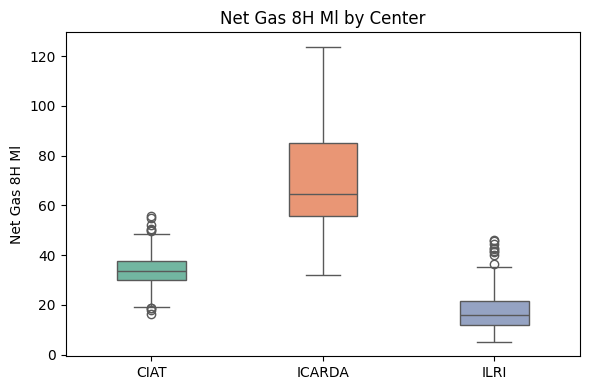

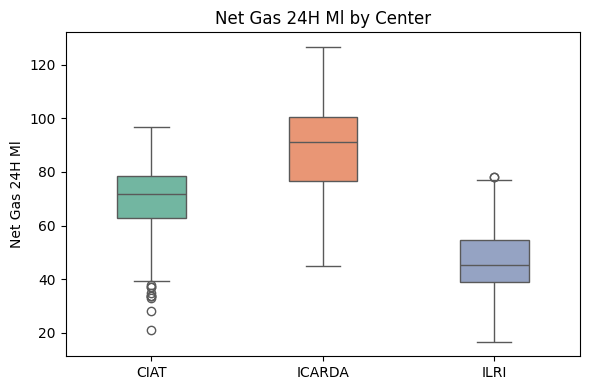

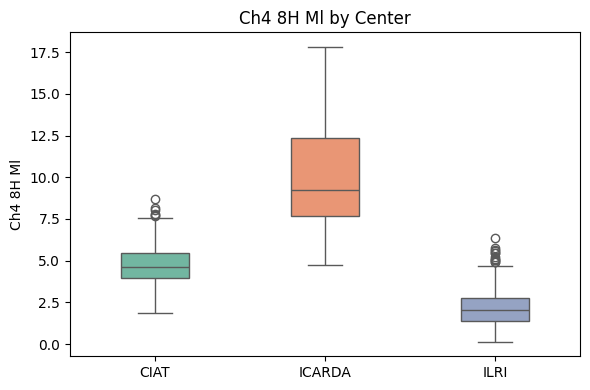

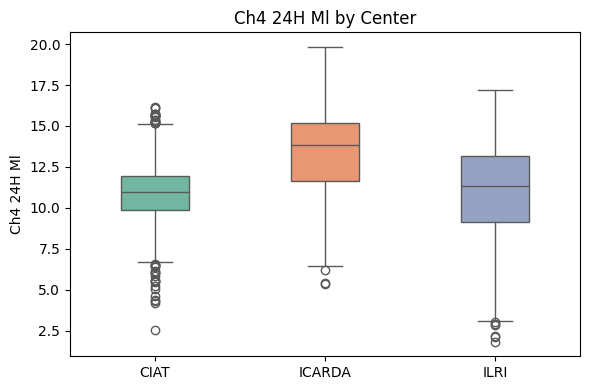

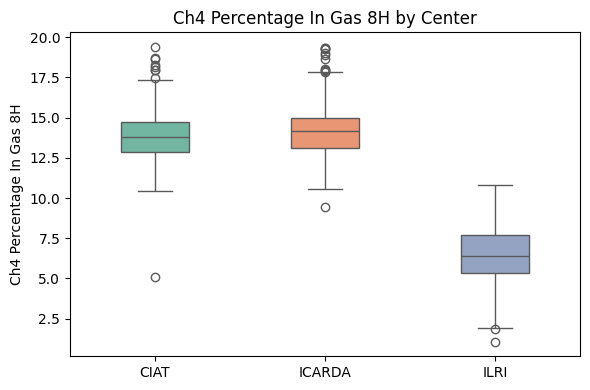

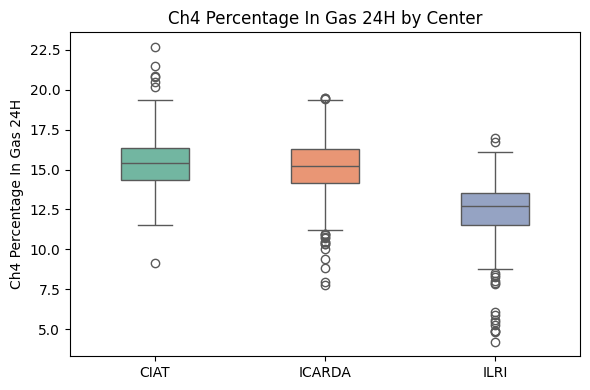

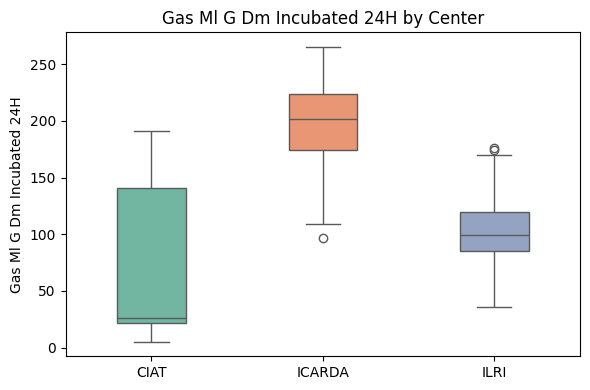

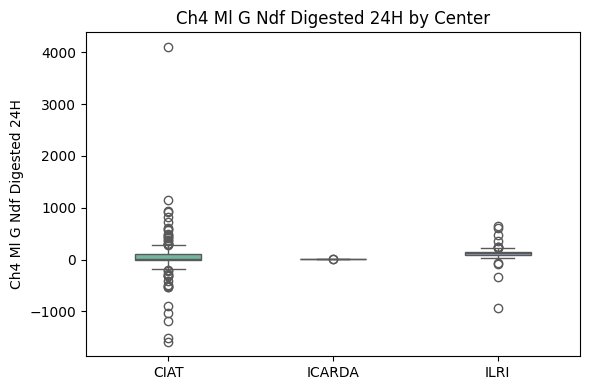

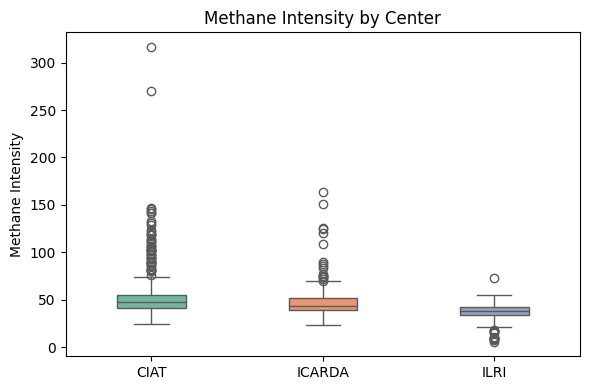

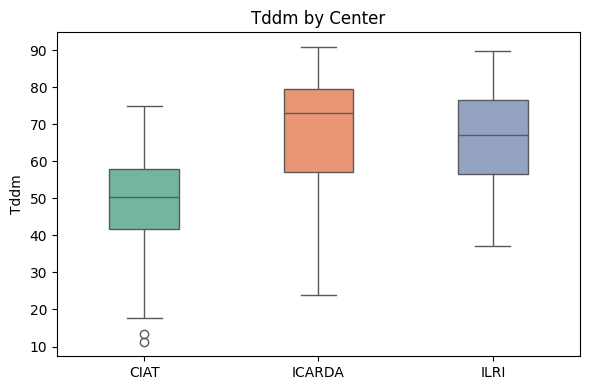

In [ ]:
# Create copies to avoid modifying original dataframes during concatenation
ciat_gas_filtered_temp = ciat_gas_filtered[numeric_columns].copy()
icarda_gas_filtered_temp = icarda_gas_filtered[numeric_columns].copy()
ilri_gas_filtered_temp = ilri_gas_filtered[numeric_columns].copy()

# Add a Center column to each dataframe
ciat_gas_filtered_temp['Center'] = 'CIAT'
icarda_gas_filtered_temp['Center'] = 'ICARDA'
ilri_gas_filtered_temp['Center'] = 'ILRI'

# Concatenate the dataframes
combined_gas_data = pd.concat([
    ciat_gas_filtered_temp,
    icarda_gas_filtered_temp,
    ilri_gas_filtered_temp
], ignore_index=True)

import os

# Define the directory to save the plots
save_dir = '/content/drive/MyDrive/lmf/output/03_19_2026/plots/'
os.makedirs(save_dir, exist_ok=True)

# Generate box plots for each numeric variable, comparing across Centers
for col in numeric_columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='Center', y=col, data=combined_gas_data, palette='Set2', width=0.4)
    plt.title(f'{col.replace("_", " ").title()} by Center')
    plt.ylabel(col.replace("_", " ").title())
    plt.xlabel('')
    #plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    # Save the plot
    filename = f"{save_dir}{col}_boxplot.png"
    plt.savefig(filename)
    plt.show()

## Individual Boxplots

In [ ]:
combined_gas_data.columns

Index(['net_gas_8h_ml', 'net_gas_24h_ml', 'ch4_8h_ml', 'ch4_24h_ml',
       'ch4_percentage_in_gas_8h', 'ch4_percentage_in_gas_24h',
       'gas_ml_g_dm_incubated_24h', 'ch4_ml_g_NDF_digested_24h',
       'methane_intensity', 'tddm', 'Center'],
      dtype='object')

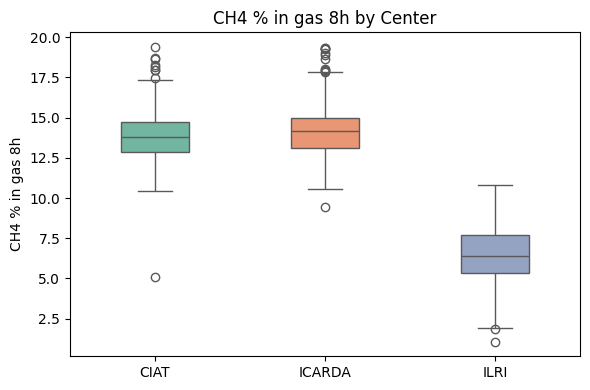

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='Center', y='ch4_percentage_in_gas_8h', data=combined_gas_data, palette='Set2', width=0.4)
plt.title("CH4 % in gas 8h by Center")
plt.ylabel("CH4 % in gas 8h")
plt.xlabel('')
plt.tight_layout()
plt.show()

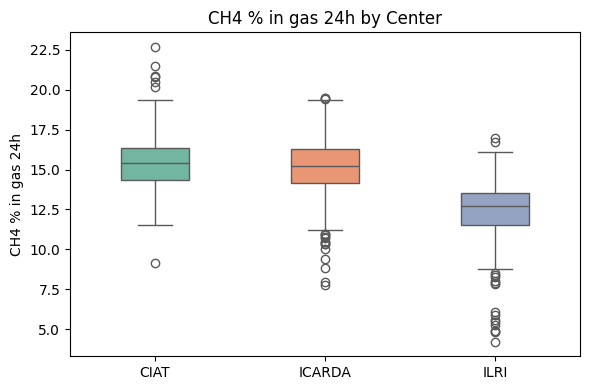

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='Center', y='ch4_percentage_in_gas_24h', data=combined_gas_data, palette='Set2', width=0.4)
plt.title("CH4 % in gas 24h by Center")
plt.ylabel("CH4 % in gas 24h")
plt.xlabel('')
plt.tight_layout()
plt.show()

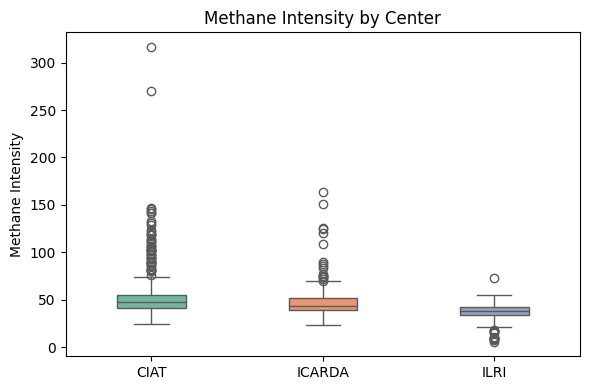

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='Center', y='methane_intensity', data=combined_gas_data, palette='Set2', width=0.4)
plt.title("Methane Intensity by Center")
plt.ylabel("Methane Intensity")
plt.xlabel('')
plt.tight_layout()
plt.show()

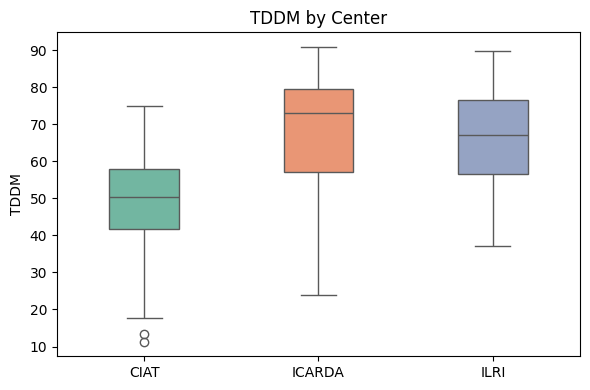

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='Center', y='tddm', data=combined_gas_data, palette='Set2', width=0.4)
plt.title("TDDM by Center")
plt.ylabel("TDDM")
plt.xlabel('')
plt.tight_layout()
plt.show()

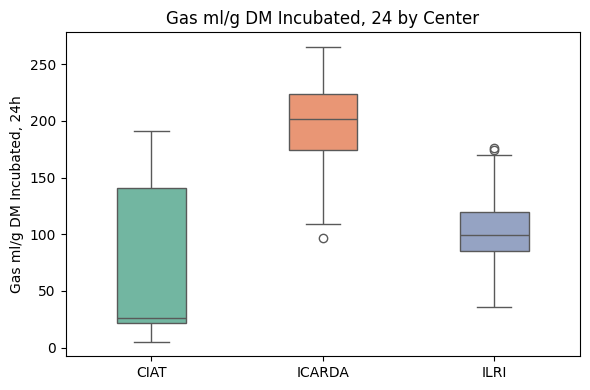

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='Center', y='gas_ml_g_dm_incubated_24h', data=combined_gas_data, palette='Set2', width=0.4)
plt.title("Gas ml/g DM Incubated, 24 by Center")
plt.ylabel("Gas ml/g DM Incubated, 24h")
plt.xlabel('')
plt.tight_layout()
plt.show()

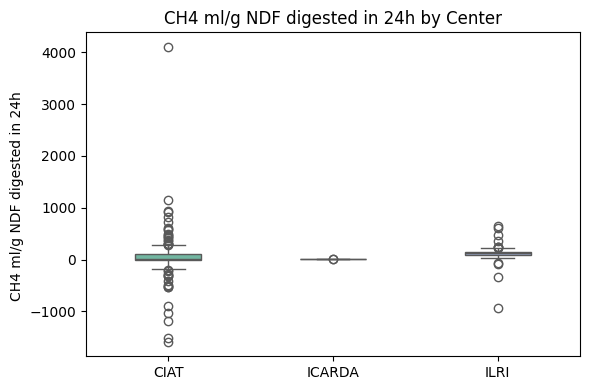

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='Center', y='ch4_ml_g_NDF_digested_24h', data=combined_gas_data, palette='Set2', width=0.4)
plt.title("CH4 ml/g NDF digested in 24h by Center")
plt.ylabel("CH4 ml/g NDF digested in 24h ")
plt.xlabel('')
plt.tight_layout()
plt.show()

# Data for Dashboard

In [ ]:
ciat_gas_dashboard = ciat_gas_filtered.drop(columns=['net_gas_8h_ml','net_gas_24h_ml','ch4_8h_ml','ch4_24h_ml','gas_ml_g_dm_incubated_24h','ch4_ml_g_NDF_digested_24h'])
icarda_gas_dashboard = icarda_gas_filtered.drop(columns=['net_gas_8h_ml','net_gas_24h_ml','ch4_8h_ml','ch4_24h_ml','gas_ml_g_dm_incubated_24h','ch4_ml_g_NDF_digested_24h'])
ilri_gas_dashboard = ilri_gas_filtered.drop(columns=['net_gas_8h_ml','net_gas_24h_ml','ch4_8h_ml','ch4_24h_ml','gas_ml_g_dm_incubated_24h','ch4_ml_g_NDF_digested_24h'])

In [ ]:
ciat_gas_dashboard = ciat_gas_dashboard.sort_values(by='id') #Sorted by id
# Icarda Dashboard was not sorted by ID due the absence of many IDs
ilri_gas_dashboard = ilri_gas_dashboard.sort_values(by='id') #Sorted by id

In [ ]:
icarda_gas_dashboard.tail()

,id_lab,id,tax_name,functional_group,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,methane_intensity,tddm
149,172,nan,Trifolium resupinatum,Herbaceous_legumes,12.73,15.01,45.00,76.43
148,171,nan,Trifolium palaestinum,Herbaceous_legumes,13.17,15.20,50.62,50.67
147,170,nan,Trifolium obscurum,Herbaceous_legumes,12.54,14.92,48.42,62.30
157,180,nan,Trifolium pauciflorum,Herbaceous_legumes,13.26,15.87,45.71,62.09
447,790,nan,Hordeum vulgare,Grass,14.52,14.42,48.09,50.83


In [ ]:
# ciat_gas_dashboard.to_csv('/content/drive/MyDrive/lmf/output/03_19_2026/ciat_gas_dashboard.csv', index=None)
# icarda_gas_dashboard.to_csv('/content/drive/MyDrive/lmf/output/03_19_2026/icarda_gas_dashboard.csv', index=None)
# ilri_gas_dashboard.to_csv('/content/drive/MyDrive/lmf/output/03_19_2026/ilri_gas_dashboard.csv', index=None)

# Counting number of replicates used for the mean estimation

In [ ]:
#numeric_columns = ['ch4_percentage_in_gas_8h', 'ch4_percentage_in_gas_24h', 'methane_intensity', 'tddm']

# Calculate the number of replicates for each 'id' from the original dataframes.
# We'll count non-NaN values for the first numeric column as a proxy for replicates.
# This count will be correctly aligned by the 'id' index.
ciat_replicates = ciat_gas_2.groupby('id')[numeric_columns[0]].count()
icarda_replicates = icarda_gas_2.groupby('id')[numeric_columns[0]].count()
ilri_replicates = ilri_gas_2.groupby('id')[numeric_columns[0]].count()

# Add the 'replicates' column to the mean dataframes
# Pandas will automatically align the Series by the 'id' index.
ciat_gas_2_mean_by_id['replicates'] = ciat_replicates
icarda_gas_2_mean_by_id['replicates'] = icarda_replicates
ilri_gas_2_mean_by_id['replicates'] = ilri_replicates

print('CIAT Gas Mean by ID with Replicates:')
display(ciat_gas_2_mean_by_id.head())

print('\nICARDA Gas Mean by ID with Replicates:')
display(icarda_gas_2_mean_by_id.head())

print('\nILRI Gas Mean by ID with Replicates:')
display(ilri_gas_2_mean_by_id.head())

CIAT Gas Mean by ID with Replicates:


,id,tax_name,functional_group,net_gas_8h_ml,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h_x,ch4_percentage_in_gas_24h,gas_ml/g_dm_incubated_24h,tddm,ch4_ml/g_NDF_digested_24h,methane_intensity,ch4_percentage_in_gas_8h_y,replicates
0,ABC-10647,Stylosanthes scabra,Herbaceous,43.31,79.20,6.90,14.88,15.90,18.79,170.35,67.34,151.04,48.31,6,NaN
1,ABC-11162,Stylosanthes scabra,Herbaceous,44.47,85.20,5.53,12.69,12.44,14.90,27.75,52.92,8.39,59.15,9,NaN
2,ABC-11194,Stylosanthes hamata,Herbaceous,33.85,70.41,5.14,12.69,15.17,18.03,151.51,59.25,184.66,46.12,6,NaN
3,ABC-11833,Stylosanthes guianensis,Herbaceous,33.95,63.44,3.95,8.36,11.63,13.19,17.60,30.51,-6.92,63.62,9,NaN
4,ABC-11998,Stylosanthes guianensis,Herbaceous,30.70,65.21,3.43,7.79,11.18,11.95,16.46,41.12,7.28,44.53,9,NaN



ICARDA Gas Mean by ID with Replicates:


,id,tax_name,functional_group,net_gas_8h_ml,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,gas_ml/g_dm_incubated_24h,tddm,ch4_ml/g_NDF_digested_24h,methane_intensity,replicates
0,101045,NaN,NaN,57.34,89.93,6.93,12.79,12.13,14.24,191.27,65.73,6.43,41.44,NaN
1,101063,NaN,NaN,54.33,92.96,7.03,13.95,12.97,15.01,194.48,53.87,5.47,54.50,NaN
2,101065,NaN,NaN,62.67,98.97,8.10,14.57,12.85,14.69,207.87,59.32,6.30,51.99,NaN
3,101076,NaN,NaN,57.24,94.65,7.50,13.73,12.95,14.47,199.71,55.19,5.43,52.55,NaN
4,101077,NaN,NaN,59.38,96.09,7.61,14.05,12.78,14.60,201.13,54.72,6.08,54.65,NaN



ILRI Gas Mean by ID with Replicates:


,id,tax_name,functional_group,net_gas_8h_ml,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,gas_ml/g_dm_incubated_24h,tddm,ch4_ml/g_NDF_digested_24h,methane_intensity,replicates
0,10003,NaN,NaN,13.18,35.92,1.15,7.18,4.48,10.17,77.46,57.79,129.65,26.84,NaN
1,10179,NaN,NaN,12.59,47.17,0.76,8.77,3.16,9.61,102.27,78.67,115.30,24.19,NaN
2,10195,NaN,NaN,21.74,61.63,2.46,15.53,5.83,13.02,133.62,80.47,157.86,41.85,NaN
3,10203,NaN,NaN,23.84,61.57,2.40,14.86,5.20,12.47,133.51,82.02,130.55,39.31,NaN
4,10207,NaN,NaN,22.57,60.54,2.21,14.38,5.06,12.28,131.28,80.68,139.04,38.68,NaN
